# Data preprocessing

In [6]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
import numpy as np
import matplotlib.pyplot as plt
import json

import warnings
warnings.filterwarnings('ignore')

# Loading pre-processed data

In [7]:
df = pd.read_parquet("cleaned_history.parquet")

with open("capital_to_country.json", "r") as f:
    capital_to_country = json.load(f)

with open("capital_to_lat.json", "r") as f:
    capital_to_lat = json.load(f)

with open("capital_to_lon.json", "r") as f:
    capital_to_lon = json.load(f)

print("Files successfully loaded!")

Files successfully loaded!


In [ ]:
aggregation_per_anno = df.groupby(['capital','year']).agg(
    mean_temp=('temp_mean_c_approx','mean'),
    std_temp=('temp_mean_c_approx','std'),
    rain_total=('rain_mm','sum'),
    days_rain=('rain_mm', lambda x: (x>1.0).sum()),
    snow_total=('snow_mm','sum'),
    days_snow=('snow_mm', lambda x: (x>1.0).sum()),
    mean_daylight=('daylight_duration_s','mean'),
    mean_sunshine=('sunshine_duration_s','mean'),
).reset_index()

aggregation_per_anno.to_csv('aggregation_per_anno.csv', index=False)

# Clusterizzazione e remapping

In [9]:
def align_clusters_sequentially(df_clusters_dict, cluster_means_dict, years, features):
    """
    Allinea i cluster in modo sequenziale: ogni anno viene allineato al precedente
    basandosi sulla distanza euclidea tra centroidi NORMALIZZATI.
    Il primo anno definisce gli indici di riferimento.
    """
    from scipy.spatial.distance import cdist
    from scipy.optimize import linear_sum_assignment
    from sklearn.preprocessing import StandardScaler
    
    aligned_clusters = {}
    aligned_means = {}
    
    # Il primo anno rimane invariato e definisce gli indici di riferimento
    aligned_clusters[years[0]] = df_clusters_dict[years[0]].copy()
    aligned_means[years[0]] = cluster_means_dict[years[0]].copy()
    
    print("="*80)
    print("ALLINEAMENTO SEQUENZIALE DEI CLUSTER (CON NORMALIZZAZIONE)")
    print("="*80)
    print(f"\n{years[0]}: Riferimento iniziale (nessun remapping)")
    print(f"Distribuzione: {aligned_clusters[years[0]]['cluster'].value_counts().sort_index().to_dict()}")
    
    # Per ogni anno successivo, allinealo al precedente
    for i in range(1, len(years)):
        prev_year = years[i-1]
        curr_year = years[i]
        
        print(f"\n{'-'*80}")
        print(f"Allineamento {curr_year} → {prev_year}")
        
        # Ottieni i centroidi del anno precedente (già allineato) e corrente (non allineato)
        prev_centroids = aligned_means[prev_year][features].values
        curr_centroids = cluster_means_dict[curr_year][features].values
        
        # Converti in DataFrame per applicare log transform alle colonne specifiche
        prev_centroids_df = pd.DataFrame(prev_centroids, columns=features)
        curr_centroids_df = pd.DataFrame(curr_centroids, columns=features)

        # Applica log transform a rain_total e snow_total
        prev_centroids_df['rain_total'] = np.log1p(prev_centroids_df['rain_total'])
        prev_centroids_df['snow_total'] = np.log1p(prev_centroids_df['snow_total'])
        curr_centroids_df['rain_total'] = np.log1p(curr_centroids_df['rain_total'])
        curr_centroids_df['snow_total'] = np.log1p(curr_centroids_df['snow_total'])
        # NORMALIZZA I CENTROIDI prima di calcolare le distanze
        # Concatena i centroidi per normalizzarli insieme (stesso scaler)
        all_centroids = np.vstack([prev_centroids_df.values, curr_centroids_df.values])
        
        scaler = StandardScaler()
        all_centroids_scaled = scaler.fit_transform(all_centroids)
        
        # Separa di nuovo i centroidi normalizzati
        prev_centroids_scaled = all_centroids_scaled[:len(prev_centroids)]
        curr_centroids_scaled = all_centroids_scaled[len(prev_centroids):]
        
        # Calcola la matrice delle distanze euclidee sui dati NORMALIZZATI
        distances = cdist(curr_centroids_scaled, prev_centroids_scaled, metric='euclidean')
        
        # Trova l'assegnamento ottimale usando Hungarian algorithm
        # row_ind = cluster corrente, col_ind = cluster precedente più vicino
        row_ind, col_ind = linear_sum_assignment(distances)
        #Assegna ogni cluster corrente al cluster precedente più coerente, minimizzando la distanza totale tra tutti gli abbinamenti

        # Crea la mappatura: cluster_corrente -> cluster_precedente
        mapping = {curr_cluster: prev_cluster for curr_cluster, prev_cluster in zip(row_ind, col_ind)}
        
        print(f"Mappatura trovata: {mapping}")
        
        # Mostra le distanze per ogni mappatura
        print(f"Distanze euclidee (su dati normalizzati):")
        for curr_cluster, prev_cluster in mapping.items():
            dist = distances[curr_cluster, prev_cluster]
            print(f"  Cluster {curr_cluster} ({curr_year}) → Cluster {prev_cluster} ({prev_year}): {dist:.4f}")
        
        # Applica la mappatura
        df_aligned = df_clusters_dict[curr_year].copy()
        df_aligned['cluster'] = df_aligned['cluster'].map(mapping)
        
        aligned_clusters[curr_year] = df_aligned
        
        # Ricalcola le medie con i nuovi indici
        cluster_means = df_aligned.groupby('cluster')[features].mean()
        aligned_means[curr_year] = cluster_means
        
        print(f"Nuova distribuzione: {df_aligned['cluster'].value_counts().sort_index().to_dict()}")
    
    print("\n" + "="*80)
    print("ALLINEAMENTO SEQUENZIALE COMPLETATO")
    print("="*80)
    
    return aligned_clusters, aligned_means

In [10]:
from sklearn.cluster import KMeans

# Esegui l'allineamento sequenziale sui dati ORIGINALI (prima del remapping manuale)
# Prima, ricrea i cluster originali senza remapping

# Lista di tutti gli anni
years = list(range(1995, 2025))

# Features da utilizzare
features = ['mean_temp', 'std_temp', 'rain_total', 'days_rain', 'snow_total', 'days_snow', 'mean_sunshine', 'mean_daylight']

# Numero di cluster
k = 5

# Ricarica i cluster originali
df_clusters_original = {}
cluster_means_original = {}

for year in years:
    # Filtra i dati per l'anno corrente
    df_year = aggregation_per_anno[aggregation_per_anno['year'] == year].copy()
    
    # Prepara i dati
    X = df_year[features].copy()
    X["rain_total"] = np.log1p(X["rain_total"])
    X["snow_total"] = np.log1p(X["snow_total"])
    
    # Scaling
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    
    # K-Means clustering
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=20)
    df_year["cluster"] = kmeans.fit_predict(X_scaled)
    
    # Aggiungi country, latitude and longitude (needed for dashboard)
    df_year['country'] = df_year['capital'].map(capital_to_country)
    df_year['lat'] = df_year['capital'].map(capital_to_lat)
    df_year['lon'] = df_year['capital'].map(capital_to_lon)

    # Salva il dataframe originale
    df_clusters_original[year] = df_year
    
    # Calcola le medie per cluster (su dati NON normalizzati per interpretabilità)
    df_year_temp = df_year.copy()
    cluster_means = df_year_temp.groupby('cluster')[features].mean()
    cluster_means_original[year] = cluster_means

# Ora applica l'allineamento sequenziale
df_clusters_anni, cluster_means_anni = align_clusters_sequentially(
    df_clusters_original,
    cluster_means_original,
    years,
    features
)

print("\n" + "="*80)
print("I cluster sono ora allineati sequenzialmente!")
print("Ogni anno è stato mappato al precedente basandosi sulla distanza euclidea")
print("calcolata su centroidi NORMALIZZATI.")
print("="*80)

for year in years:
    df_clusters_anni[year].to_csv(f'clusterization_{year}.csv', index=False)
    cluster_means_anni[year].to_csv(f'clusterization_means_{year}.csv', index=False)

ALLINEAMENTO SEQUENZIALE DEI CLUSTER (CON NORMALIZZAZIONE)

1995: Riferimento iniziale (nessun remapping)
Distribuzione: {0: 51, 1: 35, 2: 30, 3: 13, 4: 34}

--------------------------------------------------------------------------------
Allineamento 1996 → 1995
Mappatura trovata: {np.int64(0): np.int64(2), np.int64(1): np.int64(1), np.int64(2): np.int64(4), np.int64(3): np.int64(3), np.int64(4): np.int64(0)}
Distanze euclidee (su dati normalizzati):
  Cluster 0 (1996) → Cluster 2 (1995): 0.4226
  Cluster 1 (1996) → Cluster 1 (1995): 0.6174
  Cluster 2 (1996) → Cluster 4 (1995): 0.6833
  Cluster 3 (1996) → Cluster 3 (1995): 1.1539
  Cluster 4 (1996) → Cluster 0 (1995): 0.4341
Nuova distribuzione: {0: 64, 1: 22, 2: 24, 3: 28, 4: 25}

--------------------------------------------------------------------------------
Allineamento 1997 → 1996
Mappatura trovata: {np.int64(0): np.int64(1), np.int64(1): np.int64(0), np.int64(2): np.int64(2), np.int64(3): np.int64(4), np.int64(4): np.int64(3)}


# Analisi

In [11]:
import matplotlib.colors as mcolors
from matplotlib.colors import ListedColormap

cmap = plt.get_cmap("tab10")
hex_codes = [mcolors.to_hex(cmap(i)) for i in range(cmap.N)]

my_colors = {i: hex_codes[i] for i in range(len(hex_codes))}
print(my_colors)

{0: '#1f77b4', 1: '#ff7f0e', 2: '#2ca02c', 3: '#d62728', 4: '#9467bd', 5: '#8c564b', 6: '#e377c2', 7: '#7f7f7f', 8: '#bcbd22', 9: '#17becf'}


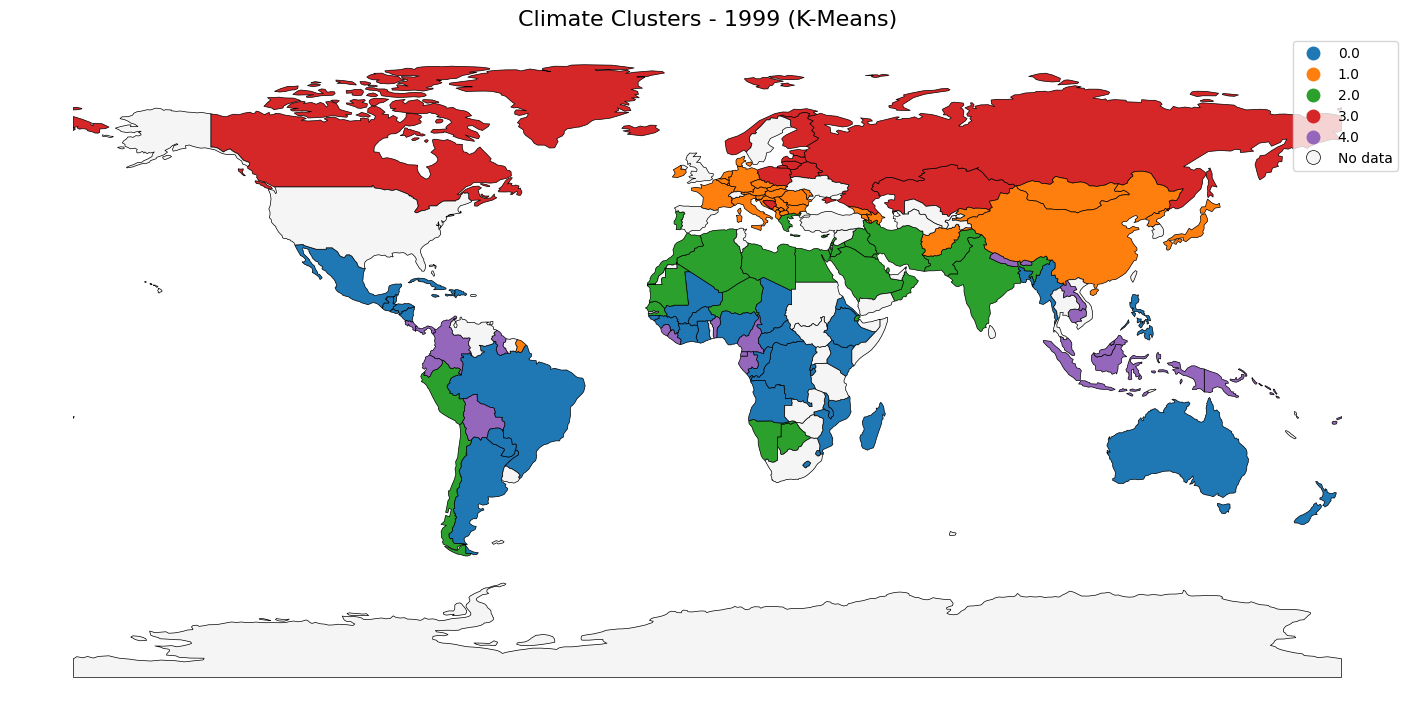

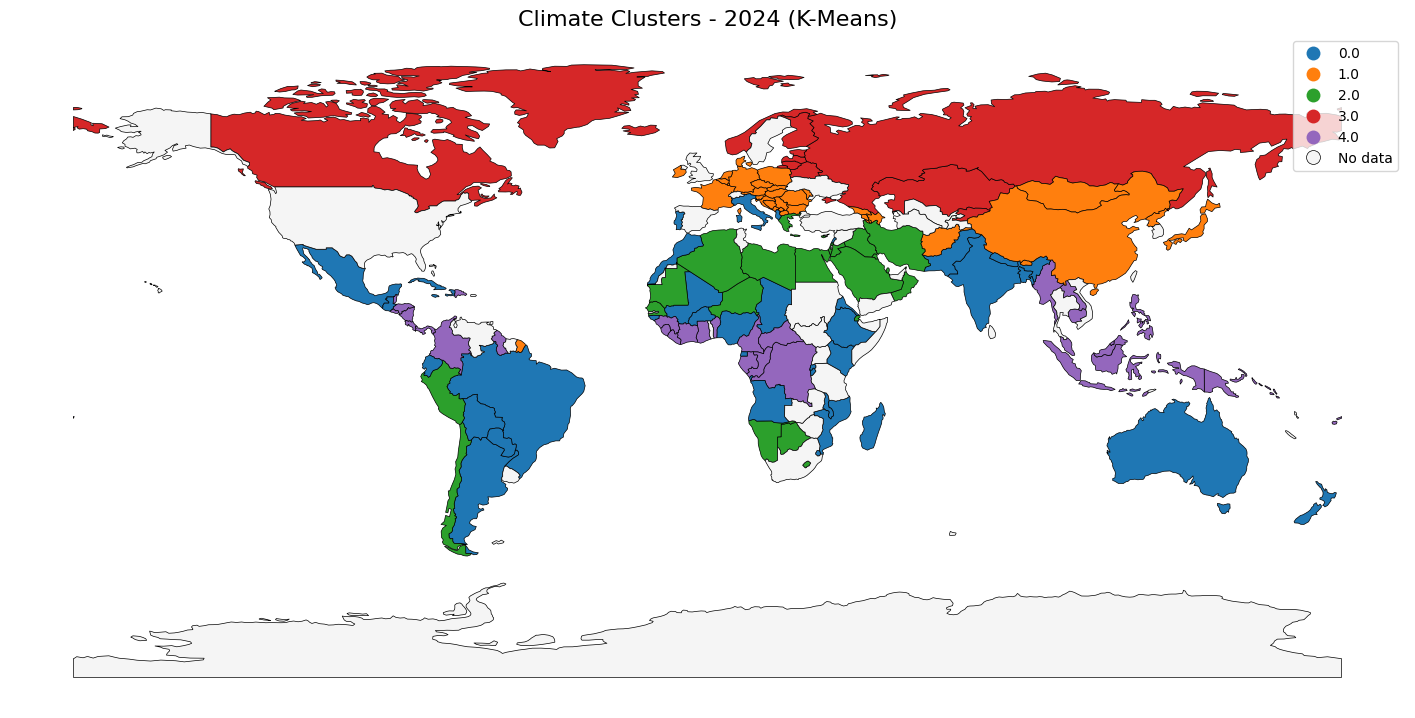

In [15]:
def plot_world_anno(df_cluster_assignment, year, n_clusters, method="K-Means", colors_to_use=my_colors):
    """
    Visualizza la mappa mondiale per un anno specifico
    """
    import geopandas as gpd
    
    # World map data
    world_url = "https://naciscdn.org/naturalearth/110m/cultural/ne_110m_admin_0_countries.zip"
    world = gpd.read_file(world_url)
    
    # We have some differences in names
    name_mapping = {
        'Bosnia and Herzegovina': 'Bosnia and Herz.',
        'Central African Republic': 'Central African Rep.',
        'Czech Republic': 'Czechia',
        'Democratic Republic of the Congo': 'Dem. Rep. Congo',
        'Dominican Republic': 'Dominican Rep.',
        'Equatorial Guinea': 'Eq. Guinea',
        'Eswatini': 'eSwatini',
        'Ivory Coast': "Côte d'Ivoire",
        'Kingdom of the Netherlands': 'Netherlands',
        "People's Republic of China": 'China',
        'Republic of the Congo': 'Congo',
        'Solomon Islands': 'Solomon Is.'
    }

    df_cluster_assignment['country'] = df_cluster_assignment['country'].replace(name_mapping)

    # Merge data
    world_clusters = world.merge(
        df_cluster_assignment,
        how="left",
        left_on="NAME",
        right_on="country"
    )

    fig, ax = plt.subplots(1, 1, figsize=(18, 9))
    
    colors_list = [colors_to_use[i] for i in range(n_clusters)]
    custom_cmap = ListedColormap(colors_list)

    world_clusters.plot(
        column="cluster",
        categorical=True,
        cmap=custom_cmap,
        linewidth=0.5,
        edgecolor="black",
        legend=True,
        ax=ax,
        missing_kwds={
            "color": "whitesmoke",
            "label": "No data"
        }
    )
    
    ax.set_title(
        f"Climate Clusters - {year} ({method})",
        fontsize=16
    )
    
    ax.axis("off")
    plt.show()

plot_world_anno(df_clusters_anni[1999], 1999, k)
plot_world_anno(df_clusters_anni[2024], 2024, k)

In [16]:
def plot_world_slider_go(df_clusters_anni, years, n_clusters, method="K-Means", colors_to_use=my_colors):
    import plotly.graph_objects as go

    # Colorscale discreta
    colorscale = []
    for i in range(n_clusters):
        c = colors_to_use[i]
        colorscale.append([i / n_clusters, c])
        colorscale.append([(i + 1) / n_clusters, c])

    frames = []

    for year in years:
        df = df_clusters_anni[year]

        frames.append(
            go.Frame(
                data=[
                    go.Choropleth(
                        locations=df["country"],
                        locationmode="country names",
                        z=df["cluster"],
                        zmin=0,
                        zmax=n_clusters - 1,
                        colorscale=colorscale,
                        showscale=True,
                        colorbar=dict(
                            title="Cluster",
                            tickvals=list(range(n_clusters)),
                            len=0.75
                        ),
                        marker_line_color="black",
                        marker_line_width=1.2,
                                                customdata=np.stack(
                            [df["capital"], df["country"], df["cluster"]],
                            axis=-1
                        ),
                        hovertemplate=(
                            "<b>%{customdata[0]}</b><br>"
                            "<span style='font-size:12px'>%{customdata[1]}</span><br>"
                            "Cluster: %{customdata[2]}"
                            "<extra></extra>"
                        ),

                    )
                ],
                name=str(year)
            )
        )

    fig = go.Figure(
        data=frames[0].data,
        layout=go.Layout(
            title=dict(
                text=f"Climate Clusters {years[0]} - {years[-1]} ({method})",
                x=0.5,
                xanchor="center",
                font=dict(size=20)
            ),
            width=1400,
            height=750,
            geo=dict(
                domain=dict(x=[0, 1], y=[0.1, 1]),
                projection_type="natural earth",
                showframe=False,
                showcountries=True,
                countrycolor="black",
                countrywidth=1.2,
                showcoastlines=False,
                bgcolor="white"
            ),
            
            updatemenus=[{
                "type": "buttons",
                "showactive": False,
                "x": 0.5,
                "y": 0.03,
                "xanchor": "center",
                "direction": "left",
                "buttons": [
                    {
                        "label": "▶ Play",
                        "method": "animate",
                        "args": [
                            None,
                            {
                                "frame": {"duration": 700, "redraw": True},
                                "fromcurrent": True,
                                "transition": {"duration": 300}
                            }
                        ]
                    },
                    {
                        "label": "⏸ Pause",
                        "method": "animate",
                        "args": [
                            [None],
                            {
                                "frame": {"duration": 0, "redraw": False},
                                "mode": "immediate"
                            }
                        ]
                    }
                ]
            }],

            sliders=[{
                "y": 0.05,
                "x": 0.1,
                "len": 0.8,
                "steps": [
                    {
                        "method": "animate",
                        "label": str(year),
                        "args": [
                            [str(year)],
                            {
                                "frame": {"duration": 0, "redraw": True},
                                "mode": "immediate"
                            }
                        ]
                    }
                    for year in years
                ],
                "currentvalue": {
                    "prefix": "Year: ",
                    "font": {"size": 16}
                }
            }]
        ),
        frames=frames
    )

    fig.show()


In [17]:
years = sorted(df_clusters_anni.keys())

plot_world_slider_go(
    df_clusters_anni=df_clusters_anni,
    years=years,
    n_clusters=k,
    method="K-Means",
    colors_to_use=my_colors
)


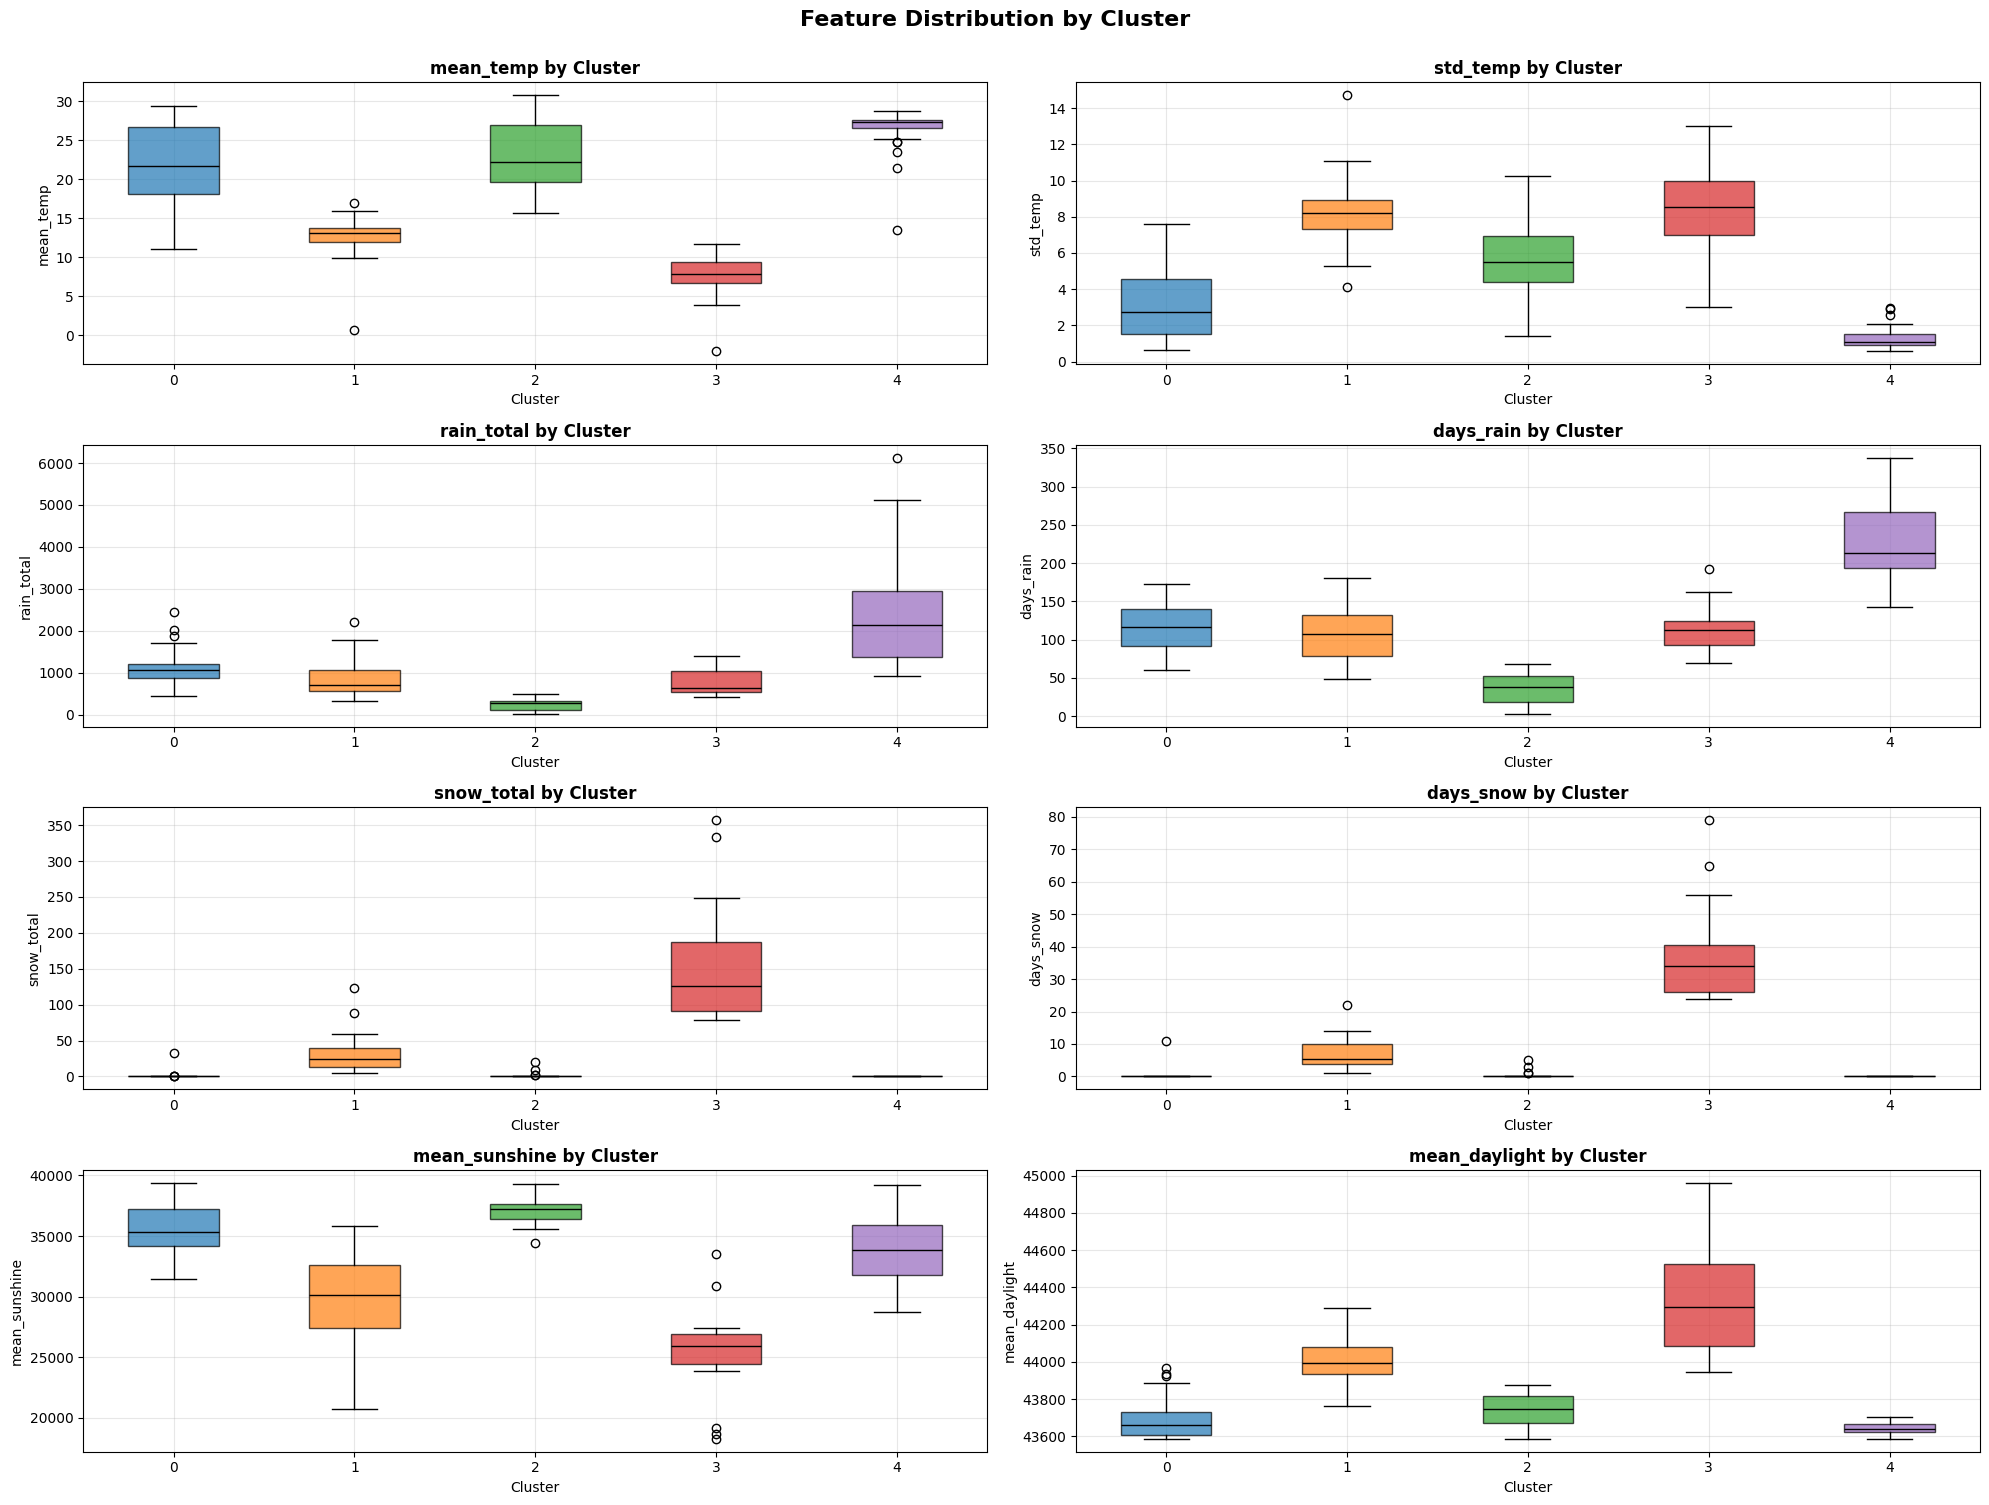

In [20]:
def plot_boxplots(df_cluster_assignment, n_clusters, colors_to_use=my_colors):
    # 8 features → 4x2 subplot
    fig, axes = plt.subplots(4, 2, figsize=(20, 15))
    axes = axes.flatten()

    for i, feature in enumerate(features):
        ax = axes[i]
        
        # Create boxplot with colors
        box_data = [df_cluster_assignment[df_cluster_assignment['cluster'] == c][feature].values for c in range(n_clusters)]
        bp = ax.boxplot(box_data, tick_labels=range(n_clusters), patch_artist=True, 
                        medianprops={'color': 'black'}, boxprops={'alpha': 0.7, 'edgecolor': 'black'})
        
        # Apply colors to boxes
        for patch, cluster_id in zip(bp['boxes'], range(n_clusters)):
            patch.set_facecolor(colors_to_use[cluster_id])
        
        # Style the plot
        ax.set_title(f'{feature} by Cluster', fontsize=12, fontweight='bold')
        ax.set_xlabel('Cluster', fontsize=10)
        ax.set_ylabel(feature, fontsize=10)
        ax.grid(True, alpha=0.3)

    plt.suptitle('Feature Distribution by Cluster', fontsize=16, fontweight='bold', y=1.00)
    plt.tight_layout()
    plt.show()

plot_boxplots(df_clusters_anni[2024], k)


EVOLUZIONE TEMPERATURE MEDIE PER CLUSTER
              1995       1996       1997       1998       1999       2000  \
cluster                                                                     
0        23.757080  23.130834  23.070052  24.502457  23.734960  22.587895   
1        10.293280  10.981402  10.170133  11.117010  11.309742  11.309567   
2        21.227324  22.742230  21.670498  22.520455  21.883530  22.449928   
3         5.706481   6.644740   5.388196   5.332397   6.140073   5.828930   
4        24.072953  23.443585  24.097477  23.611052  23.295200  24.376469   

              2001       2002       2003       2004  ...       2015  \
cluster                                              ...              
0        22.707444  22.545219  23.154763  20.978851  ...  24.450553   
1        10.205729  11.720479  10.942360  11.244616  ...  11.622240   
2        22.209035  23.801289  23.360836  24.032368  ...  21.847085   
3         5.688904   5.451448   5.240000   6.138277  ...   6.38

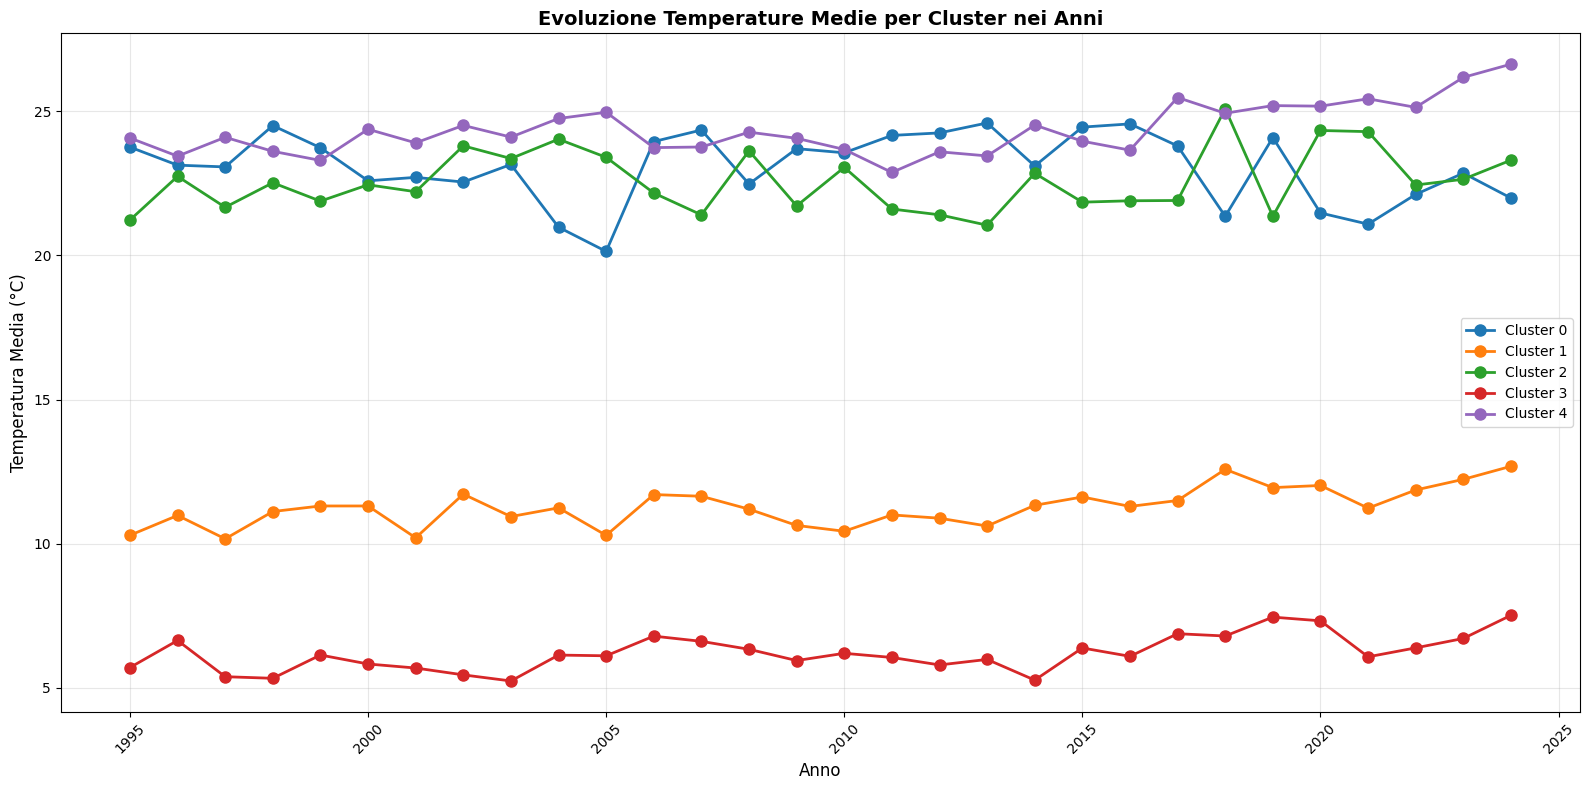


EVOLUZIONE PRECIPITAZIONI TOTALI PER CLUSTER NEGLI ANNI
                1995         1996         1997         1998         1999  \
cluster                                                                    
0        1008.343137  1195.920312   877.756364  1109.486885  1109.114035   
1         823.742857   702.409091   757.502778   678.312500   710.752941   
2         283.350000   241.741667   242.636364   213.652000   285.383333   
3         628.646154   705.914286   588.050000   710.008333   616.633333   
4        2458.752941  2819.680000  2184.378947  2636.596000  2728.644444   

                2000         2001         2002         2003         2004  ...  \
cluster                                                                   ...   
0         829.606780   816.379661   846.846154   955.706557   658.516216  ...   
1         754.594444   691.805882   903.475000   594.060000   810.594118  ...   
2         146.826316   145.900000   187.445455   169.745000    98.933333  ...   
3    

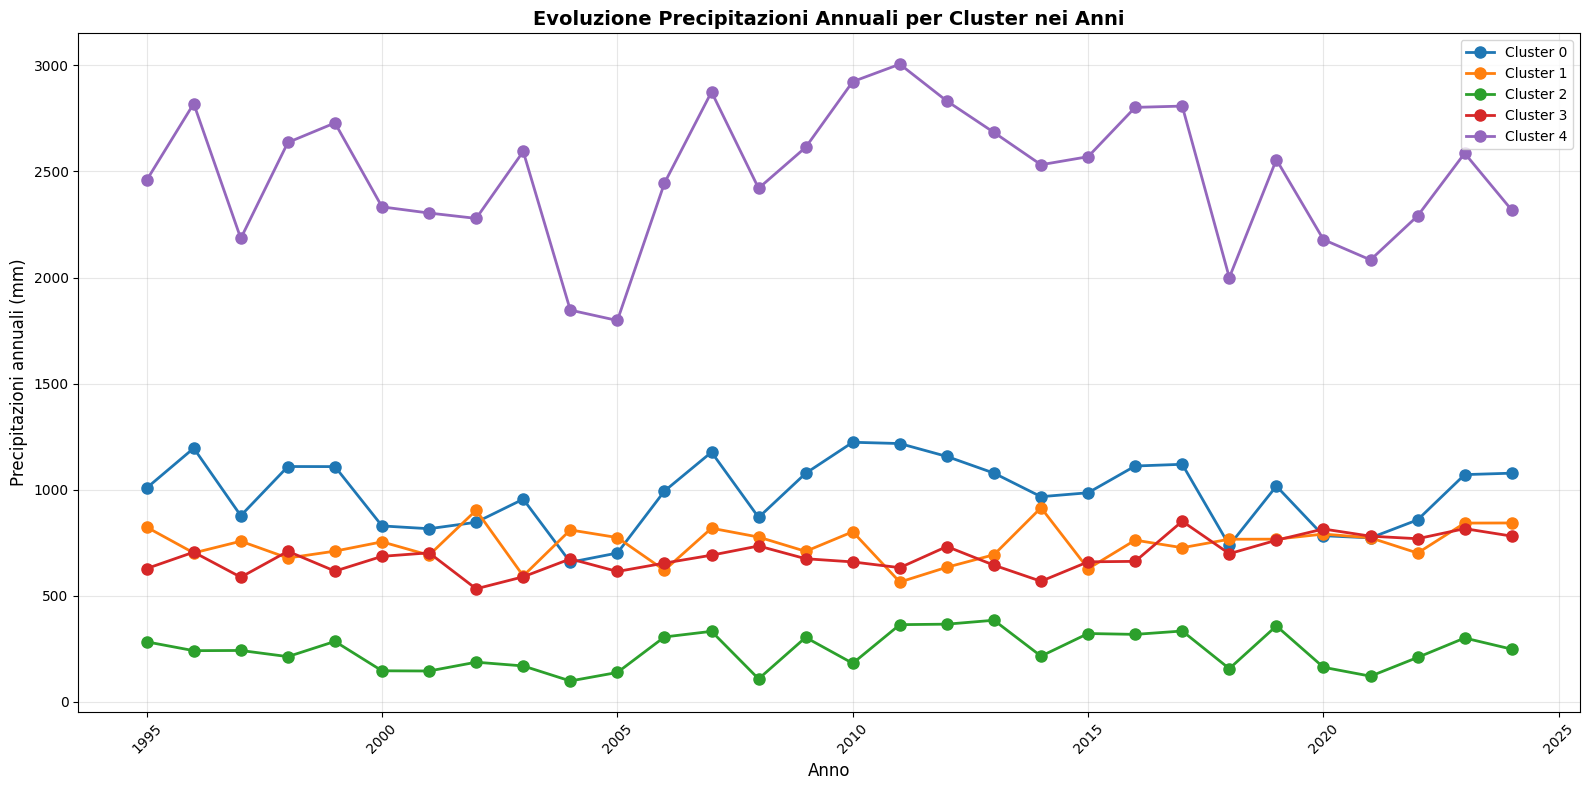

In [21]:
# Mostra l'evoluzione delle temperature dopo il remapping
print("\n" + "="*100)
print("EVOLUZIONE TEMPERATURE MEDIE PER CLUSTER")
print("="*100)

comparison_data_remapped = {}
for year in years:
    comparison_data_remapped[year] = cluster_means_anni[year]['mean_temp']

comparison_temp_remapped = pd.DataFrame(comparison_data_remapped)
print(comparison_temp_remapped.head(30))

# Grafico evoluzione temperature dopo remapping
plt.figure(figsize=(16, 8))
for cluster_id in range(k):
    if cluster_id in comparison_temp_remapped.index:
        temps = comparison_temp_remapped.loc[cluster_id]
        plt.plot(years, temps, marker='o', label=f'Cluster {cluster_id}', linewidth=2, markersize=8)

plt.xlabel('Anno', fontsize=12)
plt.ylabel('Temperatura Media (°C)', fontsize=12)
plt.title('Evoluzione Temperature Medie per Cluster nei Anni', fontsize=14, fontweight='bold')
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Mostra anche le precipitazioni
print("\n" + "="*100)
print("EVOLUZIONE PRECIPITAZIONI TOTALI PER CLUSTER NEGLI ANNI")
print("="*100)

comparison_rain_remapped = {}
for year in years:
    comparison_rain_remapped[year] = cluster_means_anni[year]['rain_total']

comparison_rain_df = pd.DataFrame(comparison_rain_remapped)
print(comparison_rain_df)


# Grafico evoluzione precipitazioni dopo remapping
plt.figure(figsize=(16, 8))
for cluster_id in range(k):
    if cluster_id in comparison_rain_df.index:
        precips = comparison_rain_df.loc[cluster_id]
        plt.plot(years, precips, marker='o', label=f'Cluster {cluster_id}', linewidth=2, markersize=8)

plt.xlabel('Anno', fontsize=12)
plt.ylabel('Precipitazioni annuali (mm)', fontsize=12)
plt.title('Evoluzione Precipitazioni Annuali per Cluster nei Anni', fontsize=14, fontweight='bold')
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [22]:
def plot_cluster_flow_sankey(df_clusters_dict, years):
    """
    Crea un diagramma Sankey che mostra come le capitali si spostano tra cluster
    """
    import plotly.graph_objects as go
    
    # Analizza i flussi tra anni consecutivi
    for i in range(len(years) - 1):
        t1 = years[i]
        t2 = years[i + 1]
        
        df1 = df_clusters_dict[t1][['capital', 'cluster']]
        df2 = df_clusters_dict[t2][['capital', 'cluster']]
        
        # Merge per trovare i movimenti
        flows = df1.merge(df2, on='capital', suffixes=('_from', '_to'))
        
        # Conta i flussi
        flow_counts = flows.groupby(['cluster_from', 'cluster_to']).size().reset_index(name='count')
        
        # Prepara i dati per Sankey
        sources = []
        targets = []
        values = []
        
        for _, row in flow_counts.iterrows():
            sources.append(int(row['cluster_from']))
            targets.append(int(row['cluster_to']) + k)  # Offset per distinguere
            values.append(row['count'])
        
        # Crea labels
        labels = [f"Cluster {i} ({t1})" for i in range(k)] + [f"Cluster {i} ({t2})" for i in range(k)]
        
        # Plot
        fig = go.Figure(data=[go.Sankey(
            node=dict(
                pad=15,
                thickness=20,
                line=dict(color="black", width=0.5),
                label=labels
            ),
            link=dict(
                source=sources,
                target=targets,
                value=values
            )
        )])
        
        fig.update_layout(
            title_text=f"Flusso di Capitali tra Cluster: {t1} → {t2}",
            font_size=12,
            height=600
        )
        fig.show()

#plot_cluster_flow_sankey(df_clusters_anni, years)

In [23]:
def plot_cluster_flow_sankey_first_to_last(df_clusters_dict, years):
    """
    Crea un diagramma Sankey che mostra come le capitali si spostano tra cluster
    dal primo all'ultimo anno
    """
    import plotly.graph_objects as go
    
    first_year = years[0]
    last_year = years[-1]
    
    print(f"Creazione Sankey: {first_year} → {last_year}")
    
    df1 = df_clusters_dict[first_year][['capital', 'cluster']]
    df2 = df_clusters_dict[last_year][['capital', 'cluster']]
    
    # Merge per trovare i movimenti
    flows = df1.merge(df2, on='capital', suffixes=('_from', '_to'))
    
    # Conta i flussi
    flow_counts = flows.groupby(['cluster_from', 'cluster_to']).size().reset_index(name='count')
    
    # Stampa statistiche
    print(f"\nStatistiche dei flussi:")
    print(f"Totale capitali tracciate: {len(flows)}")
    print(f"\nMatrice di transizione:")
    transition_matrix = flows.groupby(['cluster_from', 'cluster_to']).size().unstack(fill_value=0)
    print(transition_matrix)
    
    # Calcola stabilità per cluster
    print(f"\nStabilità per cluster (% che rimangono nello stesso cluster):")
    for cluster_id in range(k):
        same_cluster = len(flows[(flows['cluster_from'] == cluster_id) & (flows['cluster_to'] == cluster_id)])
        total_in_cluster = len(flows[flows['cluster_from'] == cluster_id])
        if total_in_cluster > 0:
            stability = (same_cluster / total_in_cluster) * 100
            print(f"  Cluster {cluster_id}: {stability:.1f}% ({same_cluster}/{total_in_cluster})")
    
    # Prepara i dati per Sankey
    sources = []
    targets = []
    values = []
    colors = []
    
    # Colori per i link
    link_colors = {
        'stable': 'rgba(0, 128, 0, 0.4)',      # Verde per chi rimane
        'change': 'rgba(255, 165, 0, 0.3)'     # Arancione per chi cambia
    }
    
    for _, row in flow_counts.iterrows():
        sources.append(int(row['cluster_from']))
        targets.append(int(row['cluster_to']) + k)  # Offset per distinguere
        values.append(row['count'])
        
        # Colora diversamente chi rimane nello stesso cluster
        if row['cluster_from'] == row['cluster_to']:
            colors.append(link_colors['stable'])
        else:
            colors.append(link_colors['change'])
    
    # Crea labels
    labels = [f"Cluster {i}\n({first_year})" for i in range(k)] + \
             [f"Cluster {i}\n({last_year})" for i in range(k)]
    
    # Colori per i nodi
    node_colors = [my_colors[i] for i in range(k)] + [my_colors[i] for i in range(k)]    
    
    # Plot
    fig = go.Figure(data=[go.Sankey(
        arrangement='snap',
        node=dict(
            pad=20,
            thickness=25,
            line=dict(color="black", width=1),
            label=labels,
            color=node_colors
        ),
        link=dict(
            source=sources,
            target=targets,
            value=values,
            color=colors
        )
    )])
    
    fig.update_layout(
        title_text=f"Flusso di Capitali tra Cluster: {first_year} → {last_year}<br>" +
                   f"<sub>Verde = rimane nello stesso cluster | Arancione = cambia cluster</sub>",
        font_size=14,
        height=700,
        width=1200
    )
    
    fig.show()
    
    return flows

# Crea il diagramma e salva i flussi
flows_first_last = plot_cluster_flow_sankey_first_to_last(df_clusters_anni, years)

Creazione Sankey: 1995 → 2024

Statistiche dei flussi:
Totale capitali tracciate: 163

Matrice di transizione:
cluster_to     0   1   2   3   4
cluster_from                    
0             28   0   2   0  21
1              2  30   0   3   0
2              6   1  23   0   0
3              0   1   0  12   0
4              8   0   0   0  26

Stabilità per cluster (% che rimangono nello stesso cluster):
  Cluster 0: 54.9% (28/51)
  Cluster 1: 85.7% (30/35)
  Cluster 2: 76.7% (23/30)
  Cluster 3: 92.3% (12/13)
  Cluster 4: 76.5% (26/34)


In [24]:
def analyze_cluster_statistics_no_plots(df_clusters_dict, cluster_means_dict, years_compare, features_analyze):
    """
    Analizza le statistiche dei cluster per anni specifici
    Mostra solo tabelle statistiche (NESSUN PLOT)
    """
    
    print("\n" + "="*100)
    print(f"ANALISI STATISTICHE CLUSTER: {years_compare[0]} vs {years_compare[1]}")
    print("="*100)
    
    # Prepara dati per entrambi gli anni
    data_comparison = {}
    
    for year in years_compare:
        print(f"\n{'-'*100}")
        print(f"ANNO {year}")
        print(f"{'-'*100}")
        
        cluster_stats = cluster_means_dict[year][features_analyze].copy()
        
        print(cluster_stats.round(2))
        print(f"\nDistribuzione capitali per cluster:")
        print(df_clusters_dict[year]['cluster'].value_counts().sort_index())
        
        data_comparison[year] = cluster_stats
    
    # Calcola variazioni assolute
    print(f"\n{'='*100}")
    print("VARIAZIONI ASSOLUTE (2024 - 1995)")
    print(f"{'='*100}")
    
    variation_absolute = data_comparison[years_compare[1]] - data_comparison[years_compare[0]]
    print(variation_absolute.round(2))
    
    # Calcola variazioni percentuali
    print(f"\n{'='*100}")
    print("VARIAZIONI PERCENTUALI (2024 - 1995) / 1995 * 100 (%)")
    print(f"{'='*100}")
    
    variation_percent = ((data_comparison[years_compare[1]] - data_comparison[years_compare[0]]) / 
                         data_comparison[years_compare[0]] * 100).replace([np.inf, -np.inf], np.nan)
    print(variation_percent.round(2))
    
    # Tabella riepilogativa per feature
    print(f"\n{'='*100}")
    print("RIEPILOGO PER FEATURE")
    print(f"{'='*100}")
    
    for feature in features_analyze:
        print(f"\n{feature.upper()}")
        print(f"{'-'*80}")
        
        summary_df = pd.DataFrame({
            f'{years_compare[0]}': data_comparison[years_compare[0]][feature],
            f'{years_compare[1]}': data_comparison[years_compare[1]][feature],
            'Differenza': variation_absolute[feature],
            'Variazione %': variation_percent[feature]
        })
        
        print(summary_df.round(2))
    
    return data_comparison, variation_absolute, variation_percent


# Esegui l'analisi
features_to_analyze = ['mean_temp', 'rain_total', 'snow_total']
years_to_compare = [1995, 2024]

comparison_data, variation_abs, variation_pct = analyze_cluster_statistics_no_plots(
    df_clusters_anni, 
    cluster_means_anni, 
    years_to_compare,
    features_to_analyze
)


ANALISI STATISTICHE CLUSTER: 1995 vs 2024

----------------------------------------------------------------------------------------------------
ANNO 1995
----------------------------------------------------------------------------------------------------
         mean_temp  rain_total  snow_total
cluster                                   
0            23.76     1008.34        0.00
1            10.29      823.74       59.45
2            21.23      283.35        0.49
3             5.71      628.65      150.70
4            24.07     2458.75        0.61

Distribuzione capitali per cluster:
cluster
0    51
1    35
2    30
3    13
4    34
Name: count, dtype: int64

----------------------------------------------------------------------------------------------------
ANNO 2024
----------------------------------------------------------------------------------------------------
         mean_temp  rain_total  snow_total
cluster                                   
0            21.99     1078.16   

# PCA analysis

In [25]:
def plot_PCA(
    df_cluster_assignment,
    year,
    colors_to_use=my_colors,
    capitals=[
        'Rome', 'Ottawa', 'Tokyo', 'Moscow', 'Mexico City',
        'Windhoek', 'Berlin', 'Luanda', 'Jakarta', 'Lima',
        'Santiago', 'Canberra', 'New Delhi', 'Algiers'
    ]
):
    import numpy as np
    import matplotlib.pyplot as plt
    from sklearn.decomposition import PCA
    from sklearn.preprocessing import StandardScaler

    # ===============================
    # 1. Filtra anno
    # ===============================
    df_year = df_cluster_assignment[df_cluster_assignment['year'] == year].copy()

    # ===============================
    # 2. Colonne numeriche
    # ===============================
    numerical_cols = df_year.select_dtypes(include=[np.number]).columns.tolist()
    numerical_cols = [c for c in numerical_cols if c not in ['year', 'cluster']]

    print(f"Colonne numeriche trovate: {numerical_cols}")

    # ===============================
    # 3. PCA
    # ===============================
    df_numeric = df_year[numerical_cols].dropna()

    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(df_numeric)

    pca = PCA(n_components=2)
    pca_result = pca.fit_transform(X_scaled)

    # ===============================
    # 4. Assegnazione CORRETTA
    # ===============================
    df_year.loc[df_numeric.index, 'pca1'] = pca_result[:, 0]
    df_year.loc[df_numeric.index, 'pca2'] = pca_result[:, 1]

    # ===============================
    # 6. Info varianza
    # ===============================
    print("\nVarianza spiegata:")
    print(f"PC1: {pca.explained_variance_ratio_[0]:.1%}")
    print(f"PC2: {pca.explained_variance_ratio_[1]:.1%}")
    print(f"Totale: {pca.explained_variance_ratio_.sum():.1%}")

    # ===============================
    # 7. Plot
    # ===============================
    plt.figure(figsize=(14, 10))

    for cluster_id in sorted(df_year['cluster'].unique()):
        cluster_data = df_year[df_year['cluster'] == cluster_id]

        plt.scatter(
            cluster_data['pca1'],
            cluster_data['pca2'],
            c=colors_to_use[cluster_id],
            label=f'Cluster {cluster_id}',
            alpha=0.7,
            s=120,
            edgecolors='black',
            linewidth=0.8
        )

    # Etichette capitali
    for capital in capitals:
        row = df_year[df_year["capital"] == capital]
        if not row.empty:
            plt.annotate(
                capital,
                (row['pca1'].values[0], row['pca2'].values[0]),
                fontsize=9,
                alpha=0.9,
                fontweight='bold'
            )

    plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%} variance)',
               fontsize=12, fontweight='bold')
    plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%} variance)',
               fontsize=12, fontweight='bold')
    plt.title(f'PCA Projection of Climate Clusters - {year}',
              fontsize=14, fontweight='bold')

    plt.legend(fontsize=11)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()


Colonne numeriche trovate: ['mean_temp', 'std_temp', 'rain_total', 'days_rain', 'snow_total', 'days_snow', 'mean_daylight', 'mean_sunshine', 'lat', 'lon']

Varianza spiegata:
PC1: 53.1%
PC2: 20.1%
Totale: 73.2%


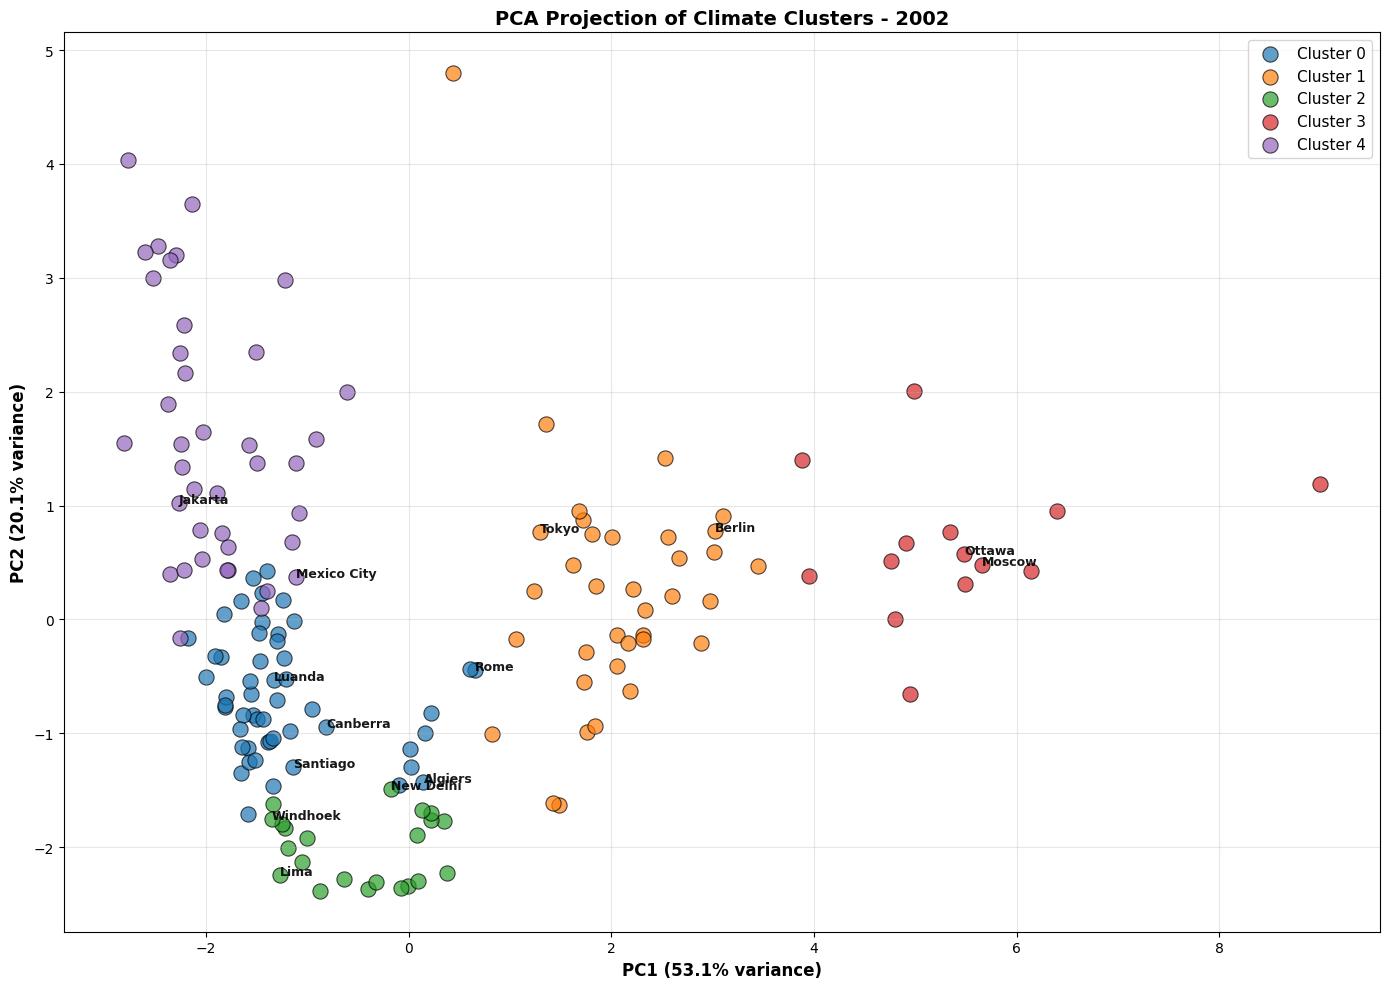

Colonne numeriche trovate: ['mean_temp', 'std_temp', 'rain_total', 'days_rain', 'snow_total', 'days_snow', 'mean_daylight', 'mean_sunshine', 'lat', 'lon']

Varianza spiegata:
PC1: 54.6%
PC2: 19.3%
Totale: 74.0%


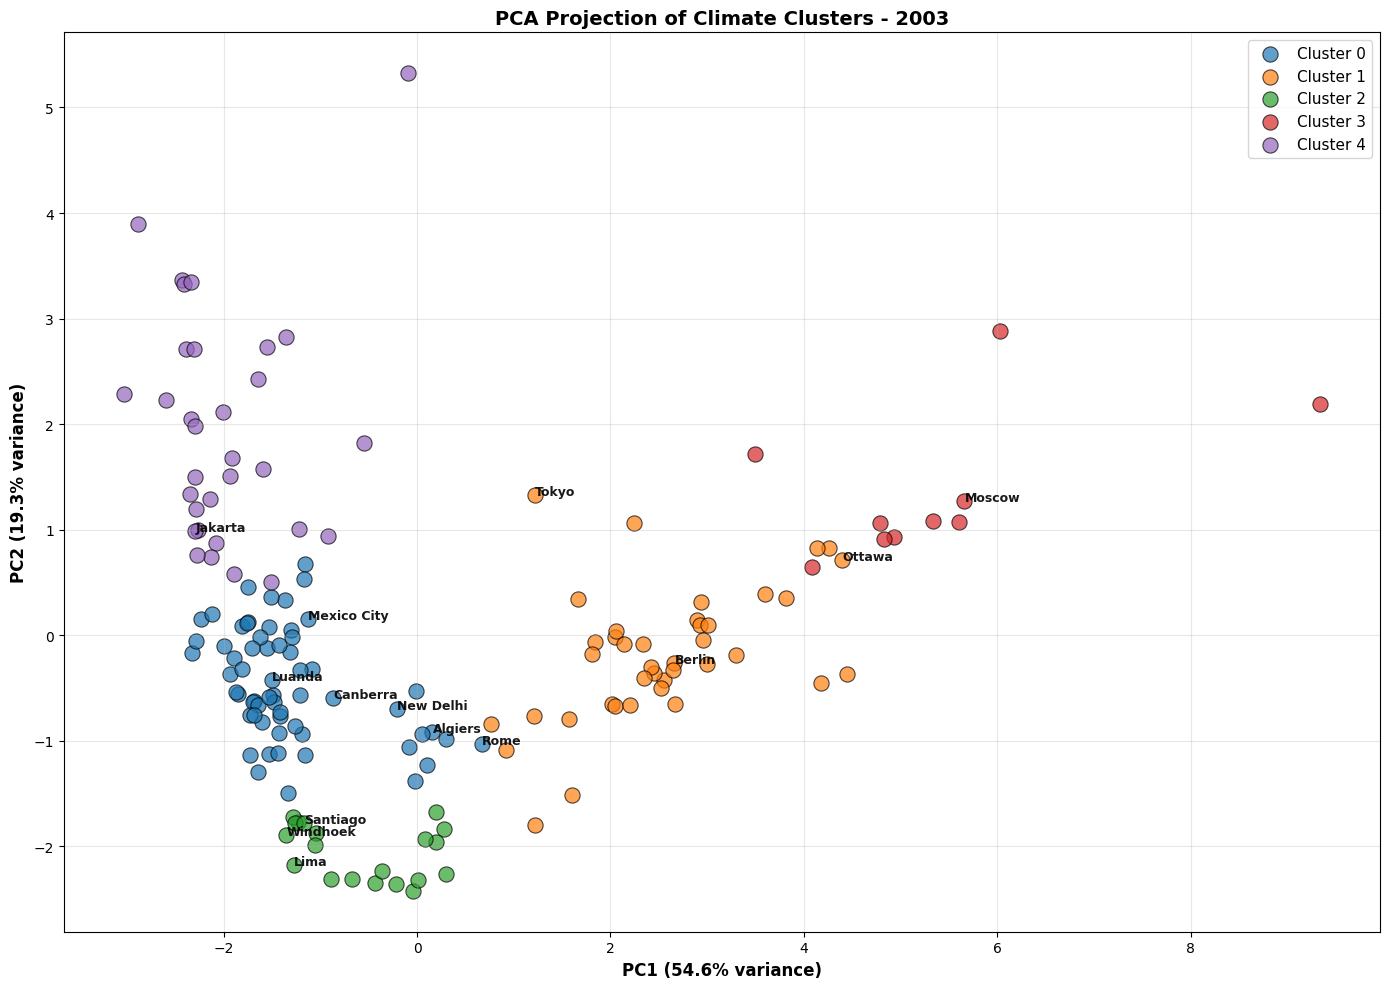

In [26]:
plot_PCA(df_clusters_anni[2002], 2002)
plot_PCA(df_clusters_anni[2003], 2003)

# Cluster globale

In [27]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Pulizia delle feature (Rimuovo mean_daylight per i motivi sopra citati)
features_to_use = [
    'mean_temp', 'std_temp', 
    'rain_total', 'days_rain', 
    'snow_total', 'days_snow', 
    'mean_sunshine'
]

# Creiamo una copia per non toccare l'originale
df_cluster = aggregation_per_anno.copy()

# 2. Controllo e riempimento NaNs
# Se 'std_temp' è NaN (es. un solo dato nell'anno), quel record è inutile.
df_cluster = df_cluster.dropna(subset=['std_temp'])
# Se snow_total è NaN, probabilmente è 0 (dipende da come sono i tuoi dati grezzi)
df_cluster[['snow_total', 'days_snow']] = df_cluster[['snow_total', 'days_snow']].fillna(0)
# Per sunshine e rain, meglio droppare o imputare con media (qui droppo per sicurezza)
df_cluster = df_cluster.dropna(subset=features_to_use)

# 3. Scaling GLOBALE (Tutti gli anni insieme)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_cluster[features_to_use])

# 4. Clustering (Esempio con 5 cluster, da ottimizzare con Elbow Method)
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
df_cluster['Cluster'] = kmeans.fit_predict(X_scaled)

# --- ANALISI DEI RISULTATI ---

# A. Interpretazione dei Cluster (Guardiamo i centroidi originali)
# Raggruppiamo per cluster e prendiamo la media delle feature ORIGINALI
cluster_profile = df_cluster.groupby('Cluster')[features_to_use].mean()

# Aggiungiamo il conteggio di quanti record ci sono per cluster
cluster_profile['count'] = df_cluster['Cluster'].value_counts()

print("Profilo Medio dei Cluster (valori reali):")
print(cluster_profile.round(2))

# B. Controllo Correlazione Pioggia (Per verificare il punto 2)
corr_rain = df_cluster[['rain_total', 'days_rain']].corr().iloc[0,1]
print(f"\nCorrelazione Totale Pioggia vs Giorni Pioggia: {corr_rain:.2f}")
if corr_rain > 0.85:
    print("ATTENZIONE: Forte ridondanza. Considera di rimuovere una delle due feature.")

Profilo Medio dei Cluster (valori reali):
         mean_temp  std_temp  rain_total  days_rain  snow_total  days_snow  \
Cluster                                                                      
0            22.52      3.92      612.84      85.81        0.57       0.16   
1             6.79      8.98      745.87     105.19      155.32      38.34   
2            24.52      1.38     2180.09     226.89        0.85       0.21   
3            10.96      8.28      683.63     101.78       40.75      10.64   

         mean_sunshine  count  
Cluster                        
0             37250.76   1992  
1             26748.86    395  
2             34463.02   1475  
3             30099.75   1028  

Correlazione Totale Pioggia vs Giorni Pioggia: 0.88
ATTENZIONE: Forte ridondanza. Considera di rimuovere una delle due feature.


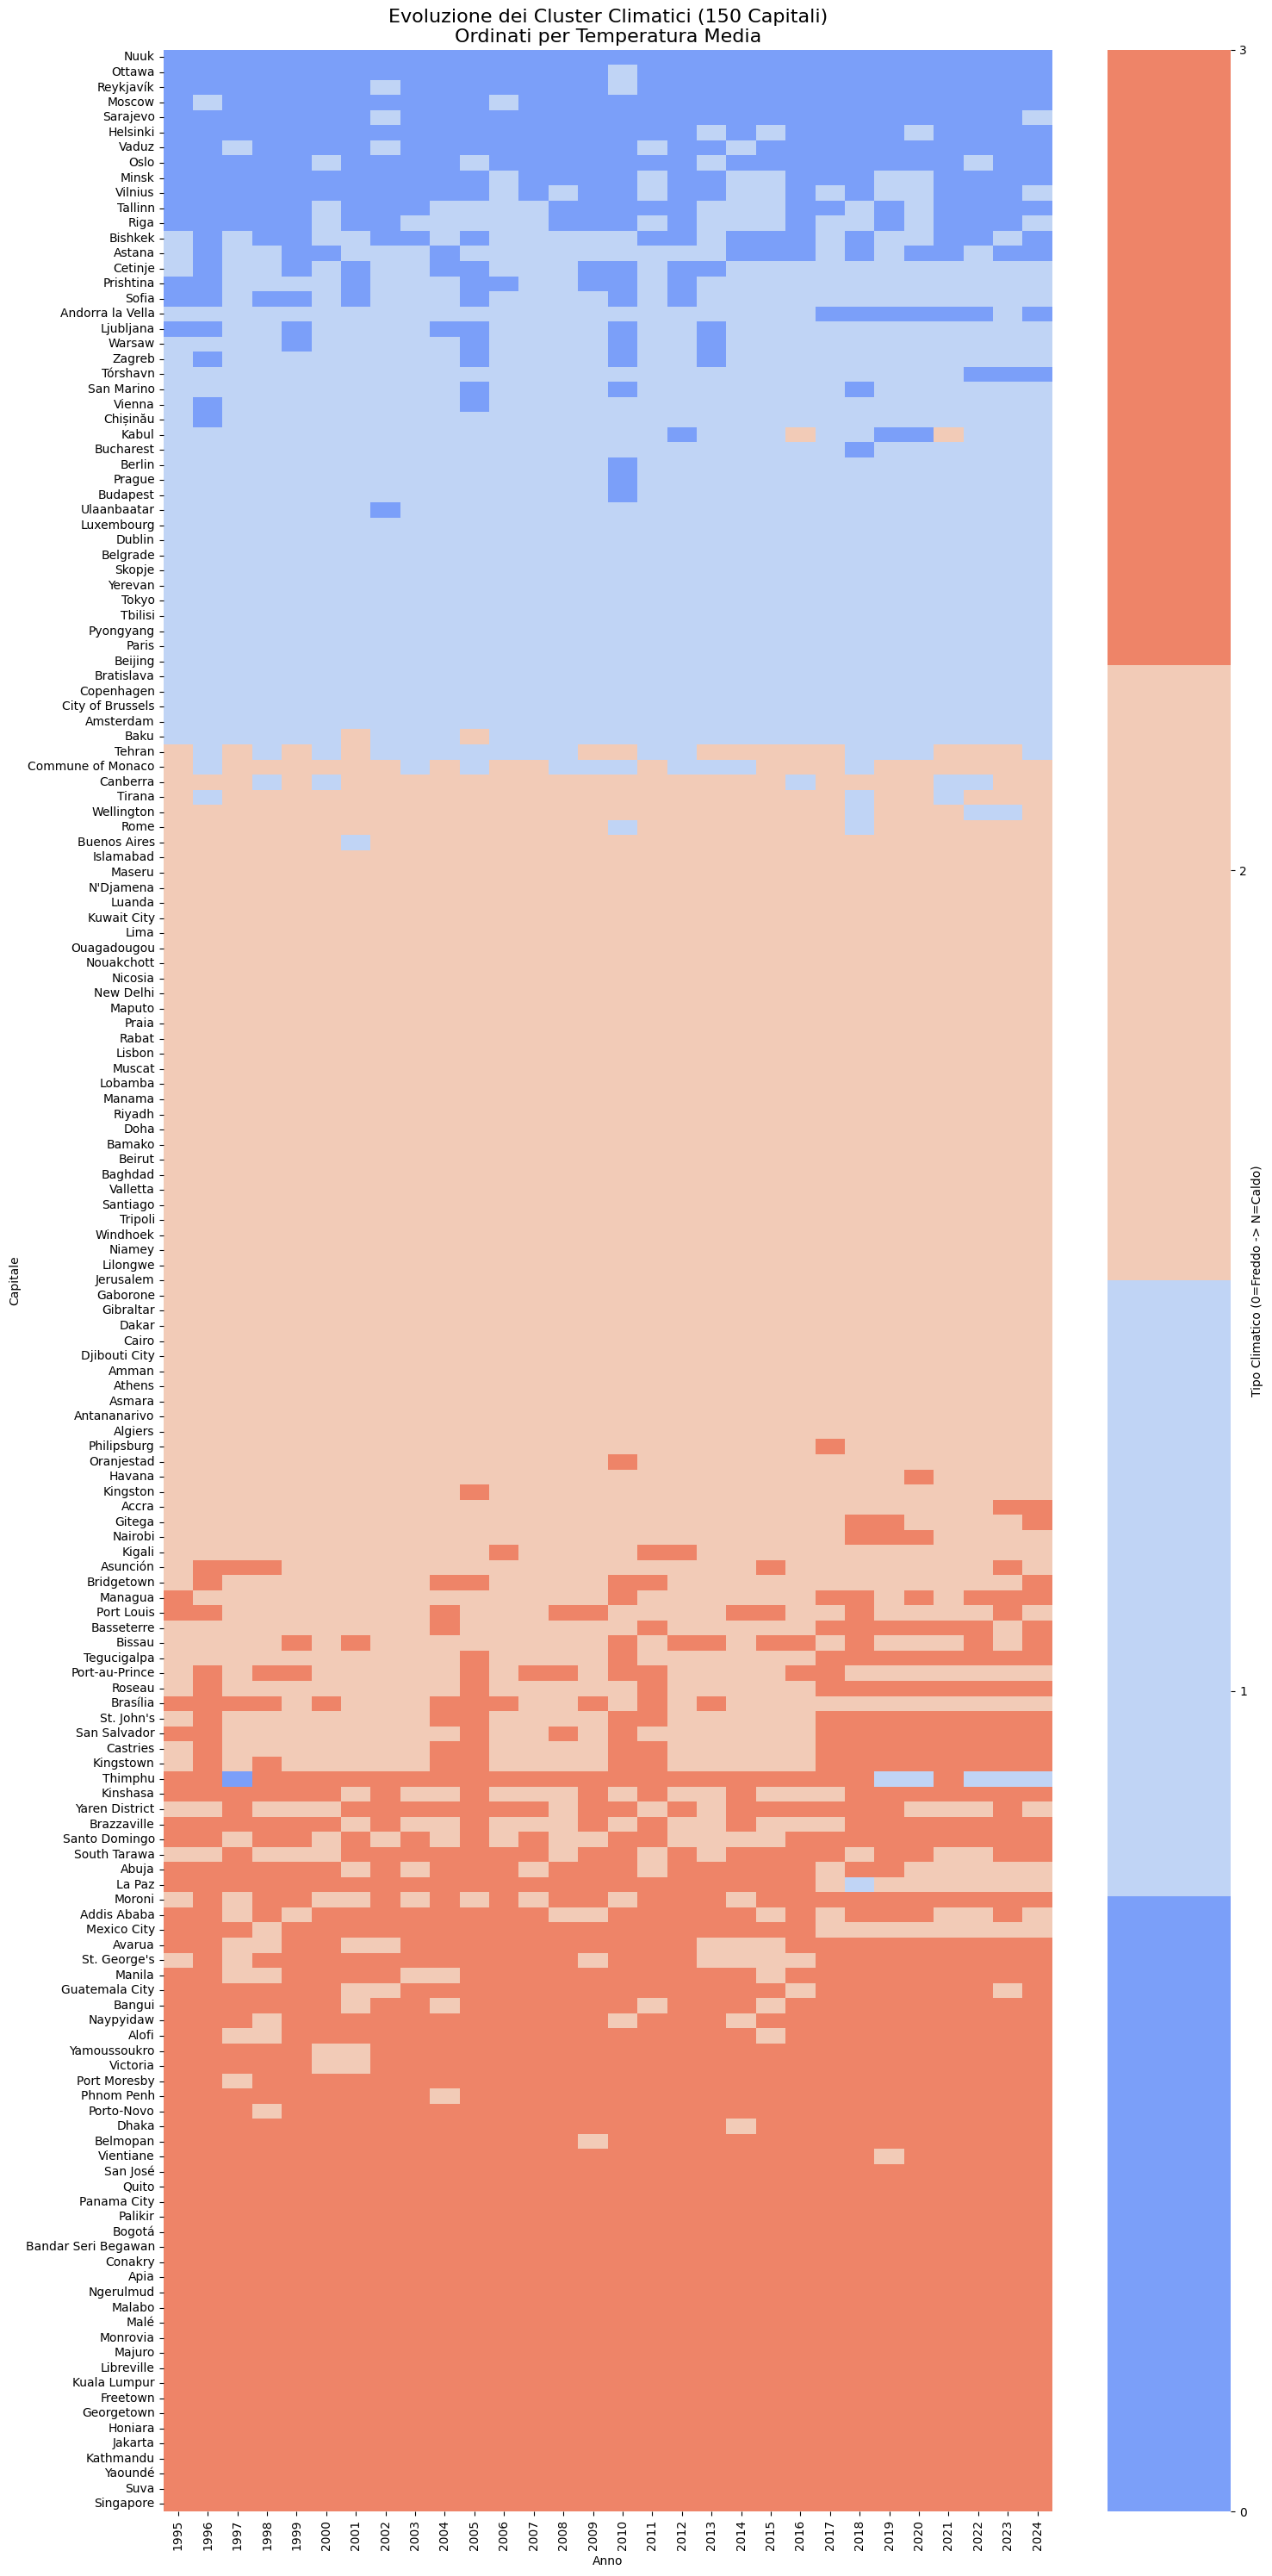

In [28]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

# Assumiamo che df_cluster sia il dataframe finale con la colonna 'Cluster'

# --- PASSO 1: Riordinare i Cluster per "Logica Fisica" (Es. Temperatura) ---
# Vogliamo che il Cluster 0 sia il più freddo e il Cluster N il più caldo.
# Questo rende la heatmap leggibile come un gradiente.
cluster_stats = df_cluster.groupby('Cluster')['mean_temp'].mean().sort_values()
mapping = {old_label: new_label for new_label, old_label in enumerate(cluster_stats.index)}

# Applichiamo il nuovo mapping
df_cluster['Cluster_Ordered'] = df_cluster['Cluster'].map(mapping)

# --- PASSO 2: Creare la Matrice ---
# Indice = Capitale, Colonne = Anno, Valori = Cluster Ordinato
heatmap_data = df_cluster.pivot(index='capital', columns='year', values='Cluster_Ordered')

# --- PASSO 3: Ordinare le Città (Righe) per pulizia visiva ---
# Ordiniamo le città in base al loro cluster medio o al cluster dell'ultimo anno
# Questo raggruppa visivamente le città simili (es. tutte le nordiche in alto, le tropicali in basso)
heatmap_data['sort_key'] = heatmap_data.mean(axis=1) 
heatmap_data = heatmap_data.sort_values('sort_key', ascending=True)
heatmap_data = heatmap_data.drop(columns='sort_key') # Rimuoviamo la chiave di sort per il plot

# --- PASSO 4: Visualizzazione ---
plt.figure(figsize=(15, 30)) # Altezza aumentata per leggere 150 città

# Creiamo una colormap discreta personalizzata (es. da Blu a Rosso/Giallo)
n_clusters = df_cluster['Cluster_Ordered'].nunique()
cmap = sns.color_palette("coolwarm", n_clusters) # o "viridis" o "Spectral_r"

ax = sns.heatmap(heatmap_data, 
                 cmap=cmap, 
                 cbar_kws={"ticks": range(n_clusters), 'label': 'Tipo Climatico (0=Freddo -> N=Caldo)'},
                 yticklabels=True) # Assicuriamoci che stampi i nomi

plt.title('Evoluzione dei Cluster Climatici (150 Capitali)\nOrdinati per Temperatura Media', fontsize=16)
plt.xlabel('Anno')
plt.ylabel('Capitale')
plt.tight_layout()
plt.show()

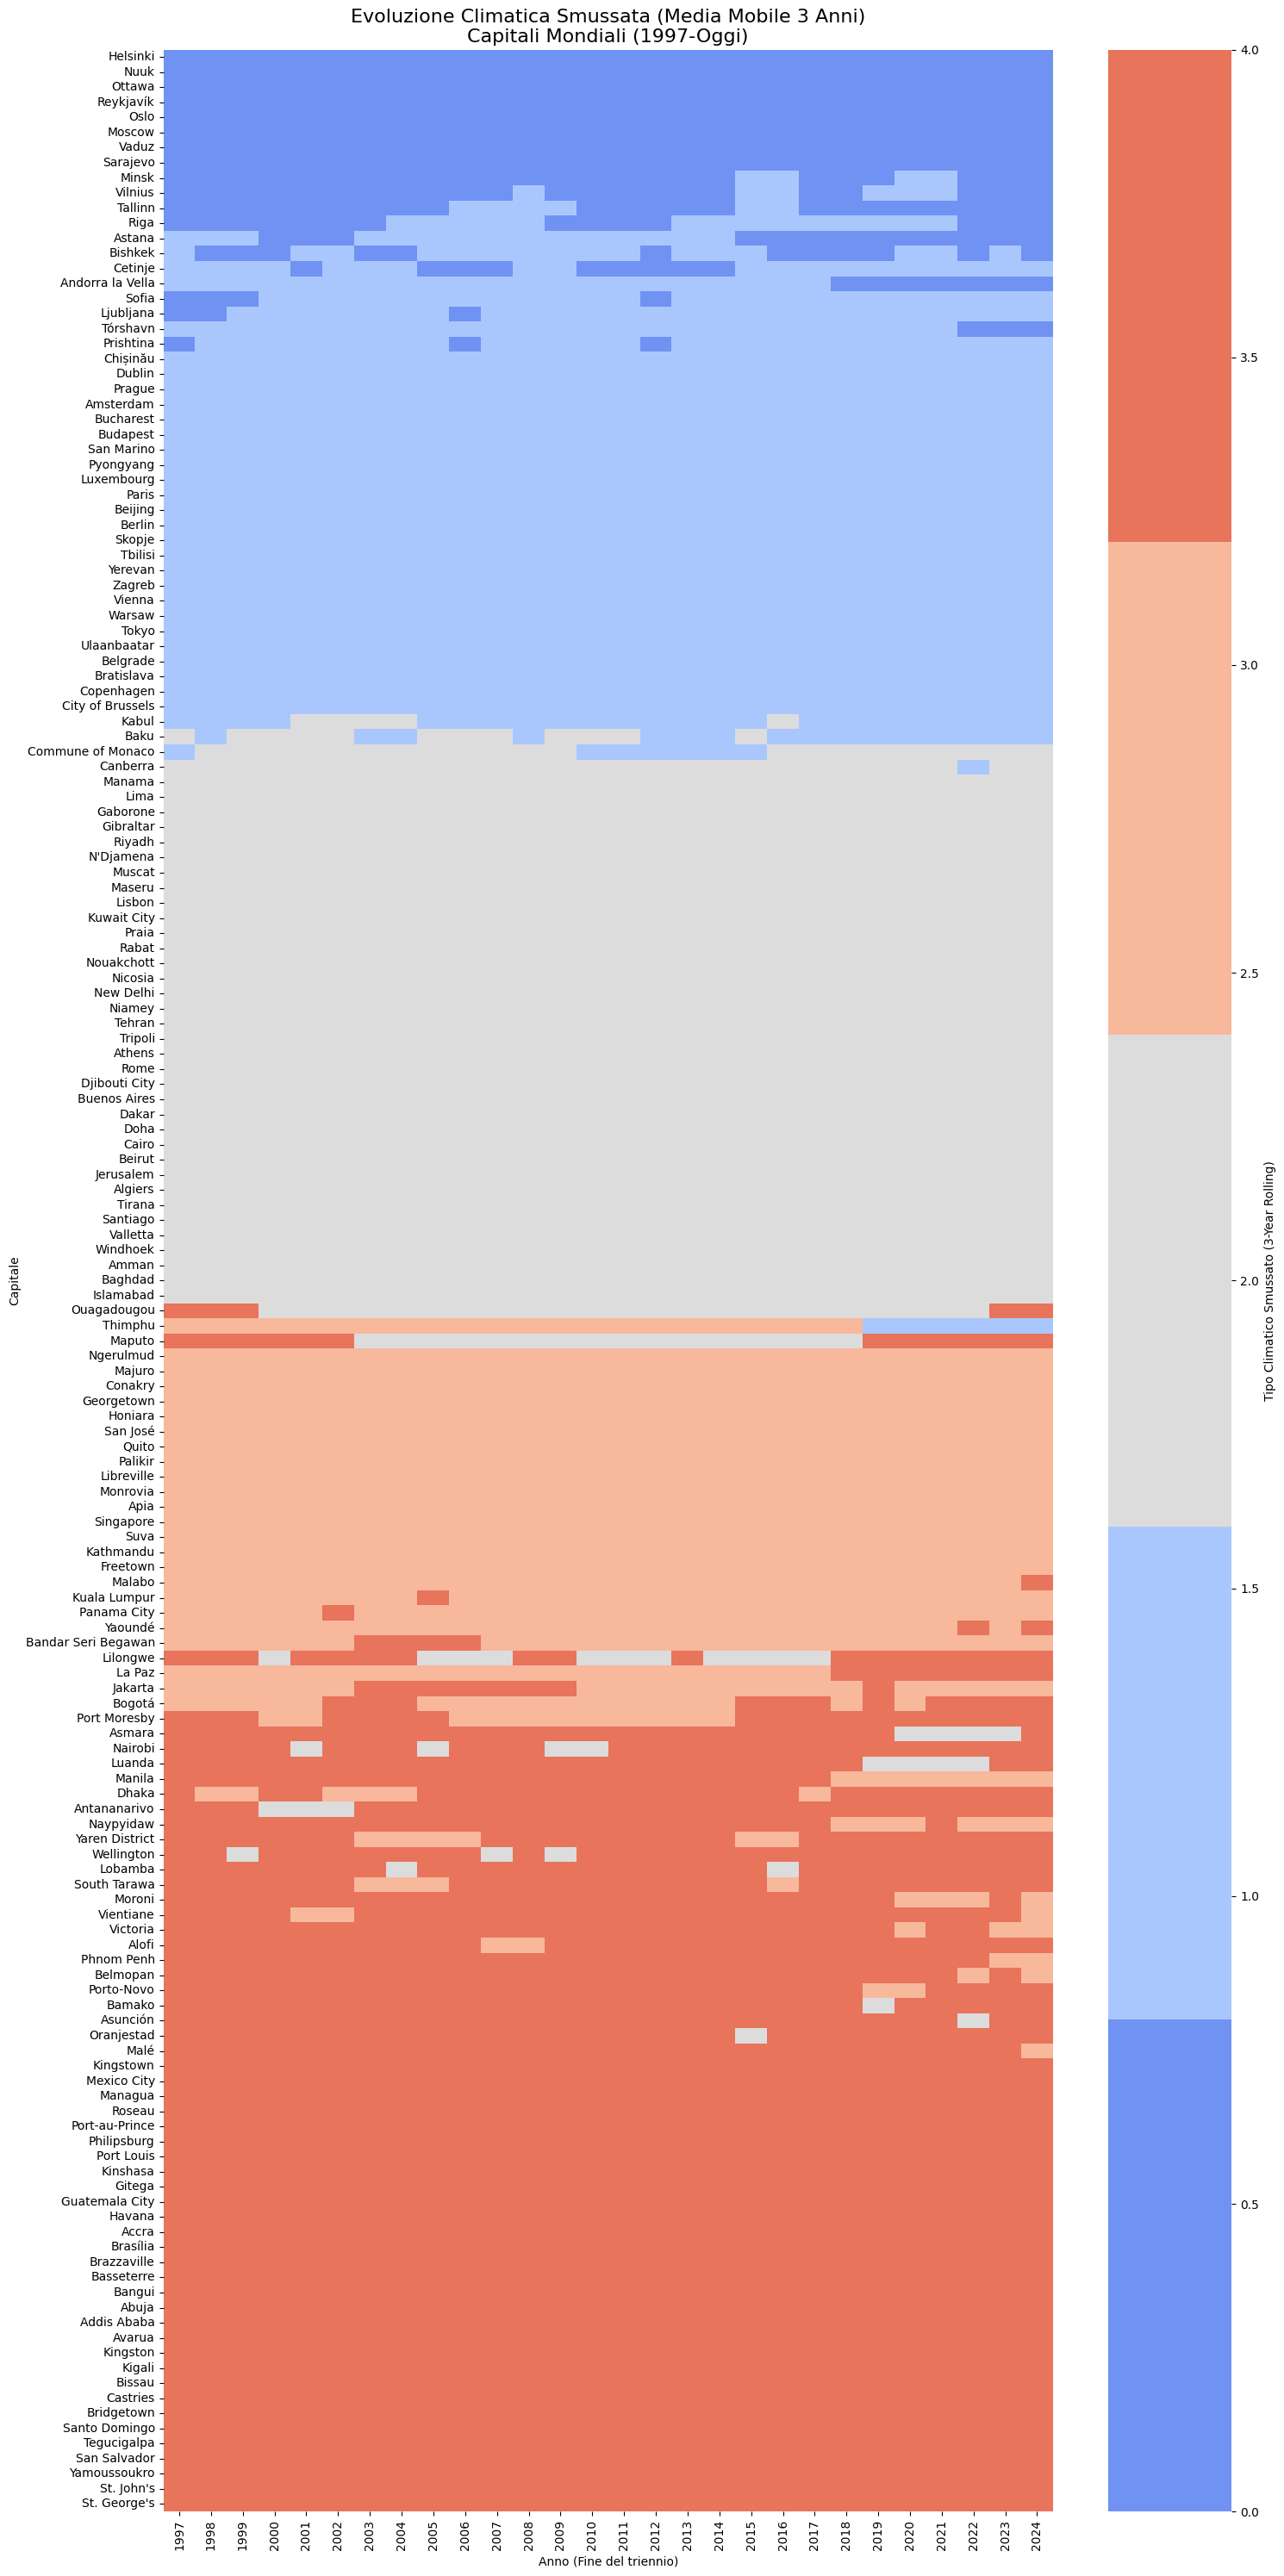

In [77]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

# 1. Preparazione della Media Mobile
# Assicuriamoci che i dati siano ordinati, altrimenti la rolling mischia anni a caso
df_sorted = aggregation_per_anno.sort_values(['capital', 'year'])

features_to_use = [
    'mean_temp', 'std_temp', 
    'rain_total', 'days_rain', 
    'snow_total', 'days_snow', 
    'mean_sunshine'
]

# Applichiamo la rolling window raggruppando per capitale
# Min_periods=3 forza ad avere tutti e 3 gli anni (quindi i primi 2 diventano NaN)
df_rolling = df_sorted.groupby('capital')[features_to_use].rolling(window=3, min_periods=3).mean().reset_index()

# Il groupby crea un livello di indice in più, dobbiamo sistemare il dataframe
# Recuperiamo l'anno corrispondente (l'indice di livello 1 corrisponde all'indice originale di df_sorted)
df_rolling['year'] = df_sorted['year'].values 

# Rimuoviamo i NaN generati dai primi 2 anni di ogni città
df_rolling = df_rolling.dropna(subset=features_to_use)

# --- 2. Scaling GLOBALE (Sui dati smussati) ---
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_rolling[features_to_use])

# --- 3. Clustering ---
# Manteniamo 5 cluster per coerenza con l'esperimento precedente
n_clusters = 5
kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
df_rolling['Cluster'] = kmeans.fit_predict(X_scaled)

# --- 4. Ordinamento per Heatmap (Come prima) ---
# Ordiniamo i cluster per temperatura media per dare senso ai colori
cluster_stats = df_rolling.groupby('Cluster')['mean_temp'].mean().sort_values()
mapping = {old: new for new, old in enumerate(cluster_stats.index)}
df_rolling['Cluster_Ordered'] = df_rolling['Cluster'].map(mapping)

# --- 5. Visualizzazione Heatmap ---
# Pivot: Righe=Capitali, Colonne=Anni
heatmap_data = df_rolling.pivot(index='capital', columns='year', values='Cluster_Ordered')

# Ordinamento estetico delle righe (basato sulla media dei cluster)
heatmap_data['sort_key'] = heatmap_data.mean(axis=1)
heatmap_data = heatmap_data.sort_values('sort_key')
heatmap_data = heatmap_data.drop(columns='sort_key')

plt.figure(figsize=(15, 30))
cmap = sns.color_palette("coolwarm", n_clusters) 

sns.heatmap(heatmap_data, 
            cmap=cmap, 
            cbar_kws={'label': 'Tipo Climatico Smussato (3-Year Rolling)'})

plt.title('Evoluzione Climatica Smussata (Media Mobile 3 Anni)\nCapitali Mondiali (1997-Oggi)', fontsize=16)
plt.xlabel('Anno (Fine del triennio)')
plt.ylabel('Capitale')
plt.tight_layout()
plt.show()